#**Importamos Librerias**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

#**Creamos Dataset**

In [11]:
data = {
    "Edad": [23, 35, 29, 41, 33, 27, 38, 31],
    "IngresoMensual": [1200, 3500, 2200, 4800, 3100, 1800, 4200, 2600],
    "Ciudad": ["Bogotá", "Cali", "Medellín", "Bogotá", "Barranquilla", "Cali", "Medellín", "Bogotá"],
    "Genero": ["F", "M", "F", "M", "F", "M", "F", "M"],
    "NivelEducativo": ["Bajo", "Alto", "Medio", "Alto", "Medio", "Bajo", "Alto", "Medio"],
    "Churn": ["No", "Sí", "No", "Sí", "No", "No", "Sí", "No"]
}

df = pd.DataFrame(data)
df

,Edad,IngresoMensual,Ciudad,Genero,NivelEducativo,Churn
0,23,1200,Bogotá,F,Bajo,No
1,35,3500,Cali,M,Alto,Sí
2,29,2200,Medellín,F,Medio,No
3,41,4800,Bogotá,M,Alto,Sí
4,33,3100,Barranquilla,F,Medio,No
5,27,1800,Cali,M,Bajo,No
6,38,4200,Medellín,F,Alto,Sí
7,31,2600,Bogotá,M,Medio,No


# Diagnóstico inicial del dataset

Antes de codificar, hay que identificar:
1. qué columnas son categóricas,
2. cuáles son nominales,
3. cuáles son ordinales,
4. qué errores conceptuales podríamos cometer.

In [5]:
df.dtypes

Edad              int64
IngresoMensual    int64
Ciudad              str
Genero              str
NivelEducativo      str
Churn               str
dtype: object

#**Interpretación del resultado**
1. int64` y `float64` indican variables numéricas.
2. object` suele indicar texto o categorías.
3. Aquí, `Ciudad`, `Genero`, `NivelEducativo` y `Churn` aparecen como `object`.

#**Entender la naturaleza de las columnas**
1. Ciudad`: nominal
2. Genero`: nominal
3. NivelEducativo`: ordinal
4. Churn`: Variable objetivo

In [7]:
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
columnas_categoricas = df.select_dtypes(include=["object","str"]).columns.tolist()

print("Columnas numéricas:", columnas_numericas)
print("Columnas categóricas:", columnas_categoricas)

Columnas numéricas: ['Edad', 'IngresoMensual']
Columnas categóricas: ['Ciudad', 'Genero', 'NivelEducativo', 'Churn']


#**Explicación**
Aquí separamos las columnas por tipo técnico de dato.

1. select_dtypes(...)` filtra columnas según el tipo.
2. columns.tolist()` devuelve los nombres como lista.

#**Analizar**
Esto solo clasifica por **tipo de almacenamiento**, no por significado analítico.  
Por eso, después de esto, el docente debe guiar una clasificación conceptual:

| Variable | Tipo técnico | Tipo analítico |
|---|---|---|
| Ciudad | object | categórica nominal |
| Genero | object | categórica nominal |
| NivelEducativo | object | categórica ordinal |
| Churn | object | variable objetivo |

In [ ]:
df_onehot = pd.get_dummies(df, columns=["Ciudad", "Genero"], dtype=int)
df_onehot

,Edad,IngresoMensual,NivelEducativo,Churn,Ciudad_Barranquilla,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín,Genero_F,Genero_M
0,23,1200,Bajo,No,0,1,0,0,1,0
1,35,3500,Alto,Sí,0,0,1,0,0,1
2,29,2200,Medio,No,0,0,0,1,1,0
3,41,4800,Alto,Sí,0,1,0,0,0,1
4,33,3100,Medio,No,1,0,0,0,1,0
5,27,1800,Bajo,No,0,0,1,0,0,1
6,38,4200,Alto,Sí,0,0,0,1,1,0
7,31,2600,Medio,No,0,1,0,0,0,1


#**Explicación línea por línea**
1.pd.get_dummies(...)`: crea variables dummy o binarias.
- `df`: DataFrame original.
- `columns=["Ciudad", "Genero"]`: indica qué columnas codificar.
- `dtype=int`: fuerza a que los valores resultantes sean 0 y 1 enteros.

#¿Qué cambió?
#Antes
`Ciudad` era una sola columna con varias etiquetas.

### Después
Ahora existen varias columnas:
- `Ciudad_Barranquilla`
- `Ciudad_Bogotá`
- `Ciudad_Cali`
- `Ciudad_Medellín`

Cada fila tiene:
- 1 en la categoría que le corresponde,
- 0 en las demás.

Lo mismo ocurre con `Genero`.

In [ ]:
comparacion_onehot = pd.concat(
    [
        df[["Ciudad", "Genero"]].head(5),
        df_onehot.filter(regex="^(Ciudad_|Genero_)").head(5)
    ],
    axis=1
)
comparacion_onehot

,Ciudad,Genero,Ciudad_Barranquilla,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Medellín,Genero_F,Genero_M
0,Bogotá,F,0,1,0,0,1,0
1,Cali,M,0,0,1,0,0,1
2,Medellín,F,0,0,0,1,1,0
3,Bogotá,M,0,1,0,0,0,1
4,Barranquilla,F,1,0,0,0,1,0


#**Antes VS Después**

La tabla anterior permite mostrar claramente el antes y el después.

## Antes
- Una sola columna `Ciudad`
- Una sola columna `Genero`

## Después
- Varias columnas binarias para cada categoría

## Ventaja pedagógica
Aquí el estudiante por fin ve que:
- el dato sigue representando lo mismo,
- pero ya está en una forma interpretable para el modelo,
- sin introducir relaciones falsas.

#**Visualización conceptual del One-Hot**

Vamos a visualizar cuántas veces aparece cada ciudad, no porque eso sea el One-Hot, sino porque ayuda a relacionar la frecuencia observada con las columnas binarias creadas.

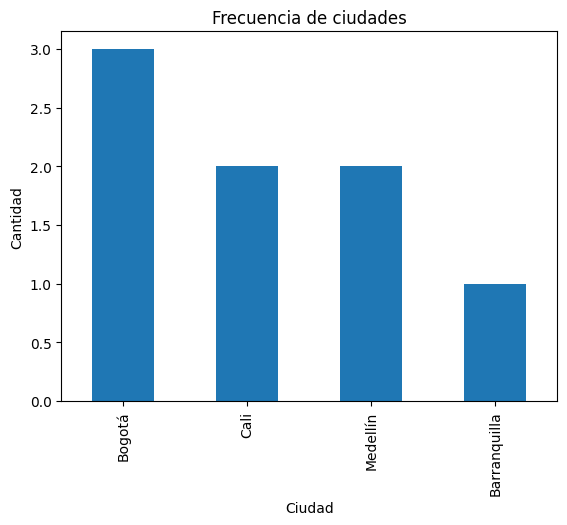

In [ ]:
df["Ciudad"].value_counts().plot(kind="bar")
plt.title("Frecuencia de ciudades")
plt.xlabel("Ciudad")
plt.ylabel("Cantidad")
plt.show()

#**Interpretación**
Esta gráfica muestra la presencia de cada categoría en el dataset.  
Cuando aplicamos One-Hot, cada una de estas categorías pasa a convertirse en una columna binaria.

No es que el gráfico codifique las ciudades; el gráfico ayuda a entender **qué categorías existen y con qué frecuencia aparecen**.

In [ ]:
df_ciudades = pd.DataFrame({
    "Ciudad": ["Bogotá", "Cali", "Medellín", "Barranquilla", "Cartagena", "Manizales", "Pasto", "Ibagué"]
})

pd.get_dummies(df_ciudades, columns=["Ciudad"], dtype=int)

,Ciudad_Barranquilla,Ciudad_Bogotá,Ciudad_Cali,Ciudad_Cartagena,Ciudad_Ibagué,Ciudad_Manizales,Ciudad_Medellín,Ciudad_Pasto
0,0,1,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0
2,0,0,0,0,0,0,1,0
3,1,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0
5,0,0,0,0,0,1,0,0
6,0,0,0,0,0,0,0,1
7,0,0,0,0,1,0,0,0


#**Enfoque profesional con `OneHotEncoder`**

Aunque `get_dummies()` es muy útil para enseñar y explorar, en entornos más profesionales suele preferirse `OneHotEncoder` dentro de un pipeline o un `ColumnTransformer`.

Esto permite:
- integrar transformaciones con más control,
- trabajar mejor con train/test,
- manejar categorías no vistas.

In [ ]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

print("Tamaño train:", X_train.shape)
print("Tamaño test:", X_test.shape)

Tamaño train: (6, 5)
Tamaño test: (2, 5)


#**¿Por qué dividimos antes?**
Porque en un flujo correcto:
- el entrenamiento se usa para aprender transformaciones,
- el test se usa para validar el comportamiento en datos aparte.

Esto prepara la lógica para explicar que las transformaciones deben ajustarse con `train` y aplicarse sobre `test`.

In [ ]:
columnas_nominales = ["Ciudad", "Genero"]

onehot = ColumnTransformer(
    transformers=[
        ("onehot_ciudad_genero", OneHotEncoder(handle_unknown="ignore", sparse_output=False), columnas_nominales)
    ],
    remainder="passthrough"
)

X_train_transformado = onehot.fit_transform(X_train)
X_test_transformado = onehot.transform(X_test)

print("Forma train transformado:", X_train_transformado.shape)
print("Forma test transformado:", X_test_transformado.shape)

Forma train transformado: (6, 8)
Forma test transformado: (2, 8)


In [ ]:
nombres_columnas = onehot.get_feature_names_out()
X_train_transformado_df = pd.DataFrame(X_train_transformado, columns=nombres_columnas)
X_train_transformado_df.head()

,onehot_ciudad_genero__Ciudad_Barranquilla,onehot_ciudad_genero__Ciudad_Bogotá,onehot_ciudad_genero__Ciudad_Medellín,onehot_ciudad_genero__Genero_F,onehot_ciudad_genero__Genero_M,remainder__Edad,remainder__IngresoMensual,remainder__NivelEducativo
0,0.0,1.0,0.0,1.0,0.0,23,1200,Bajo
1,0.0,1.0,0.0,0.0,1.0,31,2600,Medio
2,0.0,0.0,1.0,1.0,0.0,29,2200,Medio
3,1.0,0.0,0.0,1.0,0.0,33,3100,Medio
4,0.0,1.0,0.0,0.0,1.0,41,4800,Alto


#**Interpretación**
Ahora podemos ver cómo quedó el conjunto de entrenamiento después de la transformación.


#**Sección de Escalamiento**
El escalamiento busca como podemos transformar variables numericas con diferentes magnitudes para que un modelo las use de forma justa y estable. el escalamiento busca cambiar su representación numérica para que las variables trabajen en rangos comparables.

#**Descripción del Dataset**
Este dataset simula información de claientes, para ser exactos 8, utilizados para predecir si un cliente dejará o no la empresa. Este dataset consta de las siguientes variebles:

#**Variables Explicativas(X)**
1. variable edad: representa la edad de los clientes.
2. ingresosMensuales:representa el ingreso recibido mensual por cada mes
3. Ciudad: representa la ciudad donde vive cada cliente-
4. Género: representa el genero de cada cliente.
5. Nivel: representa el nivel educativo que tiene cada cliente.

#**Variable Objetivo (Y)**
Churn: representa la variable objetivo predictora.

In [8]:
data = {
    "Edad": [23, 35, 29, 41, 33, 27, 38, 31],
    "IngresoMensual": [1200, 3500, 2200, 4800, 3100, 1800, 4200, 2600],
    "Ciudad": ["Bogotá", "Cali", "Medellín", "Bogotá", "Barranquilla", "Cali", "Medellín", "Bogotá"],
    "Genero": ["F", "M", "F", "M", "F", "M", "F", "M"],
    "NivelEducativo": ["Bajo", "Alto", "Medio", "Alto", "Medio", "Bajo", "Alto", "Medio"],
    "Churn": ["No", "Sí", "No", "Sí", "No", "No", "Sí", "No"]
}

df = pd.DataFrame(data)
df

,Edad,IngresoMensual,Ciudad,Genero,NivelEducativo,Churn
0,23,1200,Bogotá,F,Bajo,No
1,35,3500,Cali,M,Alto,Sí
2,29,2200,Medellín,F,Medio,No
3,41,4800,Bogotá,M,Alto,Sí
4,33,3100,Barranquilla,F,Medio,No
5,27,1800,Cali,M,Bajo,No
6,38,4200,Medellín,F,Alto,Sí
7,31,2600,Bogotá,M,Medio,No


#**Diagn+ostico iniical del dataset**

Antes de escalar, debemaos identificar:
1. que columnas son numericas
2. que columnas son categoricas
3. cuál es la variable objetivo
4. qué columnas no deberían escalarse

In [13]:
df.dtypes

Edad              int64
IngresoMensual    int64
Ciudad              str
Genero              str
NivelEducativo      str
Churn               str
dtype: object

In [14]:
df.describe()


,Edad,IngresoMensual
count,8.000000,8.000000
mean,32.125000,2925.000000
std,5.890367,1217.432896
min,23.000000,1200.000000
25%,28.500000,2100.000000
50%,32.000000,2850.000000
75%,35.750000,3675.000000
max,41.000000,4800.000000


#**Observaciones**
Analizando los valores que arroja el describe se puede detectar que el ingreso es mas alto que el valor edad, en este casoa el modelo ignoraría la edad porque el aporte es insignificante con respecto al ingreso, por tal motivo se debe realizar el escalamiento 

#**Comparación visual antes de escalar**
Vamos a ver las variables numericas en su escala original


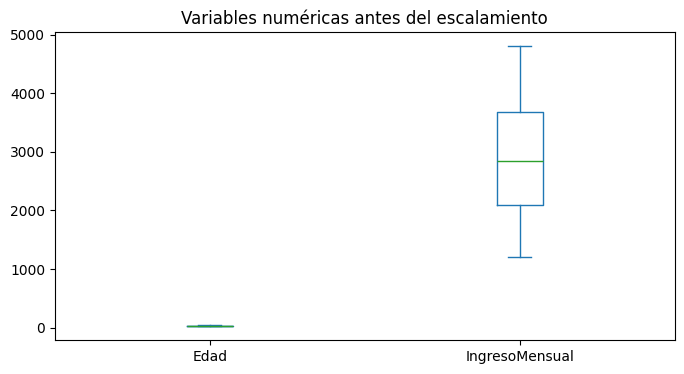

In [15]:
columnas_numericas = ["Edad", "IngresoMensual"]
                    
df[columnas_numericas].plot(kind="box", figsize=(8, 4))
plt.title("Variables numéricas antes del escalamiento")
plt.show()

#**Interpretación**
en el gráfico Ingreso Mensual domina visualmente porque sus valores son mucho más grandes. Esto indica que es necesario realizar escalamiento antes de usar ciertos modelos.

#**Aplicar Técnica StandardScaler**

In [16]:
scaler_standard = StandardScaler()

datos_standard = scaler_standard.fit_transform(df[columnas_numericas])

df_standard = pd.DataFrame(
    datos_standard,
    columns=[col + "_standard" for col in columnas_numericas]
)

df_standard
df

,Edad,IngresoMensual,Ciudad,Genero,NivelEducativo,Churn
0,23,1200,Bogotá,F,Bajo,No
1,35,3500,Cali,M,Alto,Sí
2,29,2200,Medellín,F,Medio,No
3,41,4800,Bogotá,M,Alto,Sí
4,33,3100,Barranquilla,F,Medio,No
5,27,1800,Cali,M,Bajo,No
6,38,4200,Medellín,F,Alto,Sí
7,31,2600,Bogotá,M,Medio,No


In [17]:
df

,Edad,IngresoMensual,Ciudad,Genero,NivelEducativo,Churn
0,23,1200,Bogotá,F,Bajo,No
1,35,3500,Cali,M,Alto,Sí
2,29,2200,Medellín,F,Medio,No
3,41,4800,Bogotá,M,Alto,Sí
4,33,3100,Barranquilla,F,Medio,No
5,27,1800,Cali,M,Bajo,No
6,38,4200,Medellín,F,Alto,Sí
7,31,2600,Bogotá,M,Medio,No


#**Verificamos estadisticas**
Vamos a comprobar la media y la desviación estándar después de aplicar StandardScaler.

In [18]:
print("Media después de StandardScaler:")
print(df_standard.mean())

print("Desviación estándar después de StandardScaler:")
print(df_standard.std())

Media después de StandardScaler:
Edad_standard              1.387779e-17
IngresoMensual_standard    0.000000e+00
dtype: float64
Desviación estándar después de StandardScaler:
Edad_standard              1.069045
IngresoMensual_standard    1.069045
dtype: float64


#**Observación**
StandartandardScaler funcionó perfectamente. La media es ~0 y la std poblacional es exactamente 1.0. Lo que estás viendo (std=1.069) es la desviación muestral de pandas, no un error. El escalamiento fue exitoso: ahora Edad e Ingreso están en la misma escala y el modelo puede aprender de ambas variables sin que una domine a la otra.

#**El antes y Después con StandardScaler**
Comparamos el dataset original con el dataset escalado

In [19]:
comparacion_standard = pd.concat([df[columnas_numericas], df_standard], axis=1)
comparacion_standard

,Edad,IngresoMensual,Edad_standard,IngresoMensual_standard
0,23,1200,-1.656100,-1.514747
1,35,3500,0.521785,0.504916
2,29,2200,-0.567157,-0.636633
3,41,4800,1.610727,1.646464
4,33,3100,0.158804,0.153670
5,27,1800,-0.930138,-0.987878
6,38,4200,1.066256,1.119595
7,31,2600,-0.204177,-0.285387


#**Visualizamos para ver que cambió**

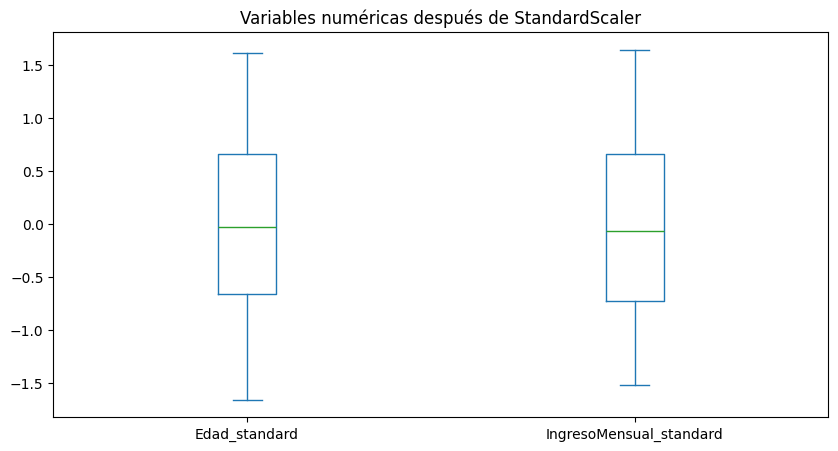

In [20]:
df_standard.plot(kind="box", figsize=(10, 5))
plt.title("Variables numéricas después de StandardScaler")
plt.show()

#**Qué cambió**
Los valores originales fueron transformados a una escala común.

Por ejemplo:
- una edad ya no aparece como `23`, sino como un valor relativo frente al promedio de edad;
- un ingreso ya no aparece como `3500`, sino como un valor relativo frente al promedio de ingresos.

El significado estadístico cambia de “valor absoluto” a “posición relativa respecto a la media”.
